# Punjab Stubble Fire — Feature Table v2

**Dataset:** NASA FIRMS — MODIS C61 + VIIRS NOAA-20 C2 · Punjab · Oct–Nov · 2018–2023

---

### Changelog vs v1

| # | Change | Why |
|---|--------|-----|
| 1 | **Confidence filter → continuous weight** | Retains evasion fires (low-conf but real) |
| 2 | **Cartesian grid × week expansion** | Zero-fire rows included — model learns what NOT-burning looks like |
| 3 | **Neighbor feature lagged by 1 week** | Fixes target leakage (was same-week, correlation 0.908 → ~0.53) |
| 4 | **NDVI anomaly + multi-scale velocity** | Deviation from baseline + harvest-rate signals replace weak raw NDVI |

---

### Notebook Structure
1. Imports
2. Load & Merge CSVs
3. Confidence Weighting (Phase 1)
4. Geographic + Seasonal Filter
5. Grid Assignment
6. Aggregate — Three Target Variants
7. Cartesian Grid × Week Expansion (Phase 2)
8. Temporal Lag Features (Phase 3)
9. Neighbor Lag Features — Leakage Fix (Phase 3)
10. NDVI Enrichment (Phase 4)
11. Correlation Diagnostics (Phase 5)
12. Export + Validation Checklist


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

print('All imports successful ✅')

All imports successful ✅


---
## 2. Load & Merge CSVs

Two NASA FIRMS sensors:
- **MODIS C61** — 1 km resolution, numeric confidence 0–100
- **VIIRS NOAA-20 C2** — 375 m resolution, categorical confidence l/n/h

We keep the same 10 columns as v1 and normalise VIIRS confidence identically.


In [2]:
COMMON_COLS = ['latitude', 'longitude', 'brightness', 'acq_date',
               'acq_time', 'satellite', 'instrument', 'confidence',
               'frp', 'daynight']

modis     = pd.read_csv('fire_archive_M-C61_720765.csv')[COMMON_COLS].copy()
viirs_n20 = pd.read_csv('fire_archive_J1V-C2_720766.csv')[COMMON_COLS].copy()

print(f'MODIS raw:  {modis.shape}')
print(f'VIIRS raw:  {viirs_n20.shape}')

# Normalise VIIRS confidence l/n/h → 30/60/90
viirs_map = {'l': 30, 'n': 60, 'h': 90}
viirs_n20['confidence'] = (
    viirs_n20['confidence'].astype(str).str.lower().map(viirs_map)
)

modis['sensor']     = 'MODIS'
viirs_n20['sensor'] = 'VIIRS'

fires = pd.concat([modis, viirs_n20], ignore_index=True)
fires['acq_date'] = pd.to_datetime(fires['acq_date'])
fires['acq_time'] = fires['acq_time'].astype(str).str.zfill(4)
fires['hour_utc'] = fires['acq_time'].str[:2].astype(int)
fires['hour_ist'] = (fires['hour_utc'] + 5) % 24
fires['year']  = fires['acq_date'].dt.year
fires['month'] = fires['acq_date'].dt.month
fires['week']  = fires['acq_date'].dt.isocalendar().week.astype(int)

before_dedup = len(fires)
fires = fires.drop_duplicates(subset=['latitude', 'longitude', 'acq_date', 'acq_time'])
print(f'\nAfter dedup: {before_dedup:,} → {len(fires):,} rows')
print(f'Sensor breakdown:\n{fires["sensor"].value_counts()}')

MODIS raw:  (514360, 10)
VIIRS raw:  (3330822, 10)



After dedup: 3,845,182 → 3,845,181 rows
Sensor breakdown:
sensor
VIIRS    3330821
MODIS     514360
Name: count, dtype: int64


---
## 3. Confidence Weighting (Phase 1 — replaces filter)

**v1 problem:** Hard threshold `confidence ≥ 50` dropped 644k detections including genuine
evasion fires (small, smoke-obscured, brief — naturally lower-confidence).

**v2 fix:** Retain everything. Scale each detection's contribution to `fire_count_weighted`
by `confidence / 100`. Low-confidence fires count less, but they're not erased.

We also compute `fire_count_filtered` (v1 logic) as a sanity-check column.
The two should correlate > 0.95 at grid-week level.


In [3]:
fires['conf_weight']  = fires['confidence'].clip(0, 100) / 100.0
fires['is_high_conf'] = (fires['confidence'] >= 50).astype(int)

low_conf_kept = (fires['confidence'] < 50).sum()
print(f'Low-confidence rows retained (v1 would have dropped): {low_conf_kept:,}')
print(f'Confidence range: {fires["confidence"].min():.0f} – {fires["confidence"].max():.0f}')

Low-confidence rows retained (v1 would have dropped): 644,734
Confidence range: 0 – 100


---
## 4. Geographic + Seasonal Filter

Same Punjab bounding box and Oct–Nov season filter as v1. Parameters are unchanged.


In [4]:
LAT_MIN, LAT_MAX = 29.7, 32.5
LON_MIN, LON_MAX = 74.0, 76.5
GRID_DEG = 0.07   # ~7 km per cell (same as v1)

punjab = fires[
    (fires['latitude']  >= LAT_MIN) & (fires['latitude']  <= LAT_MAX) &
    (fires['longitude'] >= LON_MIN) & (fires['longitude'] <= LON_MAX) &
    (fires['month'].isin([10, 11]))
].copy()

print(f'After Punjab + Oct–Nov filter: {len(punjab):,} rows')
print(f'Years: {sorted(punjab["year"].unique())}')
print(f'Sensor breakdown:\n{punjab["sensor"].value_counts()}')

After Punjab + Oct–Nov filter: 423,589 rows
Years: [np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023)]


Sensor breakdown:
sensor
VIIRS    344121
MODIS     79468
Name: count, dtype: int64


---
## 5. Grid Assignment

Identical 7 km × 7 km degree-based binning as v1. We also build a `grid_ref` lookup
table (`grid_id → grid_x, grid_y`) so we can reattach coordinates after the
cartesian expansion.


In [5]:
punjab['grid_x']  = ((punjab['longitude'] - LON_MIN) / GRID_DEG).astype(int)
punjab['grid_y']  = ((punjab['latitude']  - LAT_MIN) / GRID_DEG).astype(int)
punjab['grid_id'] = punjab['grid_x'].astype(str) + '_' + punjab['grid_y'].astype(str)

# Reference table for rejoining after cartesian expansion
grid_ref = (punjab[['grid_id', 'grid_x', 'grid_y']]
            .drop_duplicates()
            .set_index('grid_id'))

print(f'Unique 7 km grid cells: {punjab["grid_id"].nunique()}')

Unique 7 km grid cells: 1040


---
## 6. Aggregate to Grid × Week — Three Target Variants

| Column | Description |
|--------|-------------|
| `fire_count_raw` | Count of all detections (no weighting) |
| `fire_count_weighted` | Sum of `conf_weight` values — **primary target** |
| `fire_count_filtered` | Count of detections with confidence ≥ 50 — v1 baseline |

`fire_count_weighted` and `fire_count_filtered` should correlate > 0.95 — if not, the confidence
normalisation has diverged unexpectedly between sensors.


Aggregated: (28340, 11)
Corr(fire_count_weighted, fire_count_filtered) = 0.9989  ✅ OK


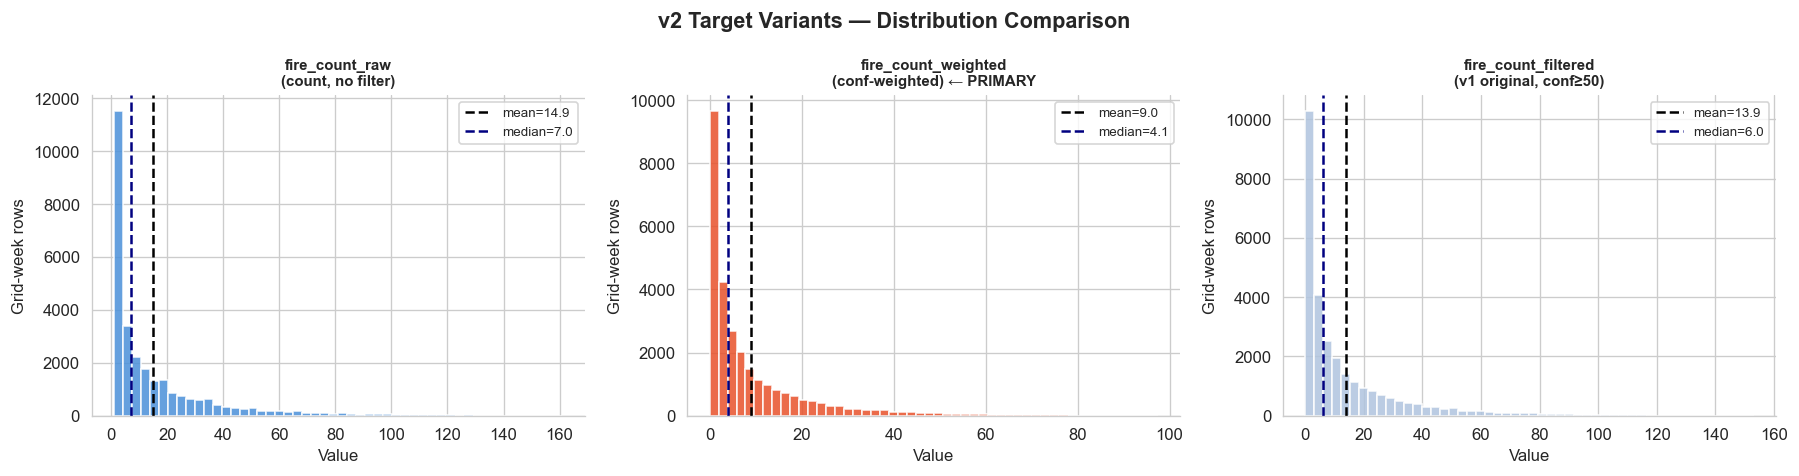

In [6]:
agg_df = (
    punjab.groupby(['grid_id', 'year', 'week'])
    .agg(
        fire_count_raw      = ('acq_date',    'count'),
        fire_count_weighted = ('conf_weight', 'sum'),
        fire_count_filtered = ('is_high_conf','sum'),
        avg_frp             = ('frp',         'mean'),
        avg_brightness      = ('brightness',  'mean'),
        avg_confidence      = ('confidence',  'mean'),
        night_fire_pct      = ('daynight',    lambda x: (x == 'N').mean()),
        conf_weight_sum     = ('conf_weight', 'sum'),
    )
    .reset_index()
)

print(f'Aggregated: {agg_df.shape}')

r_sanity = agg_df[['fire_count_weighted','fire_count_filtered']].corr().iloc[0,1]
print(f'Corr(fire_count_weighted, fire_count_filtered) = {r_sanity:.4f}  '
      f'{"✅ OK" if r_sanity > 0.95 else "⚠️ WARNING"}')

# ── Plot three target distributions ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
targets = ['fire_count_raw', 'fire_count_weighted', 'fire_count_filtered']
titles  = ['fire_count_raw\n(count, no filter)',
           'fire_count_weighted\n(conf-weighted) ← PRIMARY',
           'fire_count_filtered\n(v1 original, conf≥50)']
colors  = ['#4A90D9', '#E8512A', '#B0C4DE']

for ax, col, title, color in zip(axes, targets, titles, colors):
    data = agg_df[col]
    ax.hist(data, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='black', linestyle='--', lw=1.5,
               label=f'mean={data.mean():.1f}')
    ax.axvline(data.median(), color='navy',  linestyle='--', lw=1.5,
               label=f'median={data.median():.1f}')
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Grid-week rows')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('v2 Target Variants — Distribution Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_v2_target_comparison.png', bbox_inches='tight')
plt.show()

---
## 7. Cartesian Grid × Week Expansion (Phase 2)

**v1 problem:** Only rows where fires were observed existed — ~28k rows, all `fire_count > 0`.
The model never saw what a non-burning cell looks like.

**v2 fix:** Expand to every possible (grid_id, year, week) combination. Grid cells with no
observed fires in a given week get `fire_count_* = 0`; intensity features remain NaN
(XGBoost routes NaN to a learnable split direction, which is preferable to imputing zeros
for FRP/brightness where NaN truly means "no fire observed").

Expected: ~50% zero-fire rows.


In [7]:
all_grid_ids = sorted(punjab['grid_id'].unique())
all_years    = sorted(punjab['year'].unique())
season_weeks = list(range(40, 49))   # ISO weeks 40–48 cover Oct 1 – Nov 30

full_index = pd.MultiIndex.from_product(
    [all_grid_ids, all_years, season_weeks],
    names=['grid_id', 'year', 'week']
).to_frame(index=False)

expected_rows = len(all_grid_ids) * len(all_years) * len(season_weeks)
print(f'Cartesian product: {len(all_grid_ids)} cells × '
      f'{len(all_years)} years × {len(season_weeks)} weeks = {expected_rows:,}')

grid_week = full_index.merge(agg_df, on=['grid_id', 'year', 'week'], how='left')

# Fill count columns with 0; intensity columns stay NaN
count_cols = ['fire_count_raw','fire_count_weighted','fire_count_filtered','conf_weight_sum']
grid_week[count_cols] = grid_week[count_cols].fillna(0)

assert len(grid_week) == expected_rows, f'Row mismatch: {len(grid_week)} ≠ {expected_rows}'

zero_pct = (grid_week['fire_count_weighted'] == 0).mean() * 100
print(f'Total rows:       {len(grid_week):,}')
print(f'Zero-fire rows:   {(grid_week["fire_count_weighted"]==0).sum():,}  ({zero_pct:.1f}%)')
assert 30 < zero_pct < 80, f'Zero-fire % = {zero_pct:.1f}% — unexpected'
print('✅ Row count and zero-fire proportion look correct')

# Reattach grid_x, grid_y from reference table
grid_week = grid_week.join(grid_ref, on='grid_id')

Cartesian product: 1040 cells × 6 years × 9 weeks = 56,160
Total rows:       56,160
Zero-fire rows:   27,987  (49.8%)
✅ Row count and zero-fire proportion look correct


---
## 8. Temporal Lag Features (Phase 3)

Rebuilt on the full cartesian grid (so lags never leak across zero-fill rows).
- `fire_count_last_week` — same cell, previous ISO week (within same year)
- `same_week_last_year` — same cell + week, prior year
- `3yr_avg` — 3-year rolling mean of `fire_count_weighted` for same (cell, week)


In [8]:
grid_week = grid_week.sort_values(['grid_id', 'year', 'week']).reset_index(drop=True)

# fire_count_last_week — shift 1 within (grid_id, year)
grid_week['fire_count_last_week'] = (
    grid_week.groupby(['grid_id', 'year'])['fire_count_weighted']
             .shift(1).fillna(0)
)

# same_week_last_year — shift year forward by 1 and merge back
prev_year = grid_week[['grid_id','year','week','fire_count_weighted']].copy()
prev_year['year'] = prev_year['year'] + 1
prev_year = prev_year.rename(columns={'fire_count_weighted': 'same_week_last_year'})
grid_week = grid_week.merge(prev_year, on=['grid_id','year','week'], how='left')
grid_week['same_week_last_year'] = grid_week['same_week_last_year'].fillna(0)

# 3yr_avg — use transform to avoid groupby-apply column loss
grid_week = grid_week.sort_values(['grid_id', 'week', 'year']).reset_index(drop=True)
grid_week['3yr_avg'] = (
    grid_week.groupby(['grid_id', 'week'])['fire_count_weighted']
             .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean().fillna(0))
)
grid_week = grid_week.sort_values(['grid_id', 'year', 'week']).reset_index(drop=True)

print('Temporal lag features done.')
print(f'Columns: {grid_week.columns.tolist()}')

Temporal lag features done.
Columns: ['grid_id', 'year', 'week', 'fire_count_raw', 'fire_count_weighted', 'fire_count_filtered', 'avg_frp', 'avg_brightness', 'avg_confidence', 'night_fire_pct', 'conf_weight_sum', 'grid_x', 'grid_y', 'fire_count_last_week', 'same_week_last_year', '3yr_avg']


---
## 9. Neighbor Lag Features — Leakage Fix (Phase 3)

**v1 problem:** `neighbor_fire_count` summed fires in 8 adjacent cells at the **same week**
as the target → correlation 0.908 with `fire_count`. At inference time you don't have
current-week neighbor data.

**v2 fix:** Two lagged variants:
- `neighbor_fires_last_week` — neighbor fires at week t−1 (temporal lag)
- `neighbor_fires_last_year` — neighbor fires at the same week, year y−1

Expected post-fix correlation: ~0.3–0.55 (real spatial spillover, not leakage).


In [9]:
print('Building neighbor lookup...')

lookup = (
    grid_week[['grid_x', 'grid_y', 'year', 'week', 'fire_count_weighted']]
    .set_index(['grid_x', 'grid_y', 'year', 'week'])['fire_count_weighted']
    .to_dict()
)

def neighbor_fires(gx, gy, yr, wk):
    total = 0.0
    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            if dx == 0 and dy == 0:
                continue
            total += lookup.get((gx + dx, gy + dy, yr, wk), 0.0)
    return total

# neighbor_fires_last_week: query neighbors at (year, week-1)
grid_week['neighbor_fires_last_week'] = [
    neighbor_fires(gx, gy, yr, wk - 1)
    for gx, gy, yr, wk in zip(
        grid_week['grid_x'], grid_week['grid_y'],
        grid_week['year'],   grid_week['week']
    )
]

# neighbor_fires_last_year: query neighbors at (year-1, same week)
grid_week['neighbor_fires_last_year'] = [
    neighbor_fires(gx, gy, yr - 1, wk)
    for gx, gy, yr, wk in zip(
        grid_week['grid_x'], grid_week['grid_y'],
        grid_week['year'],   grid_week['week']
    )
]

grid_week['week_of_season'] = (grid_week['week'] - 39).clip(1, 9)

r_neigh = grid_week[['fire_count_weighted','neighbor_fires_last_week']].corr().iloc[0,1]
print(f'Corr(fire_count_weighted, neighbor_fires_last_week) = {r_neigh:.4f}  '
      f'{"✅ leakage fixed" if abs(r_neigh) < 0.7 else "⚠️ WARNING: still high"}')
print('(v1 original neighbor_fire_count was ~0.908 — now lagged)')

Building neighbor lookup...
Corr(fire_count_weighted, neighbor_fires_last_week) = 0.5295  ✅ leakage fixed
(v1 original neighbor_fire_count was ~0.908 — now lagged)


---
## 10. NDVI Enrichment (Phase 4)

Three improvements over v1's raw NDVI:

1. **NDVI_anomaly** — deviation from historical baseline (mean for same grid_id + week
   across 2018–2022 training years). Isolates "abnormally un-green for this time of year."
2. **NDVI_velocity_Xwk** — week-over-week change at 1-, 2-, and 4-week scales.
   Multi-scale captures both sharp harvest drops and gradual senescence.
3. **NDVI_acceleration** — second derivative (how fast the rate of change is changing).
   A sudden acceleration (sharper than usual drop) signals imminent burning.

> Note: NDVI baseline uses only 2018–2022 to avoid data leakage into the 2023 test year.


In [10]:
ndvi_v1 = pd.read_csv('punjab_feature_table_with_ndvi.csv')
print(f'NDVI source file columns: {ndvi_v1.columns.tolist()}')

# v1 stored week_of_season; map back to ISO week for merge key
ndvi_v1['week'] = ndvi_v1['week_of_season'] + 39
ndvi_cols = ['grid_id', 'year', 'week', 'NDVI', 'EVI']

# Deduplicate on merge key (v1 may have duplicate rows per grid-week)
ndvi_merge = (ndvi_v1[ndvi_cols]
              .groupby(['grid_id', 'year', 'week'], as_index=False)[['NDVI','EVI']].mean())
print(f'NDVI merge table after dedup: {ndvi_merge.shape}')

grid_week = grid_week.merge(ndvi_merge, on=['grid_id','year','week'], how='left')
print(f'After NDVI merge: {grid_week.shape} | NDVI NaN rate: {grid_week["NDVI"].isna().mean()*100:.1f}%')

# ── NDVI baseline (training years only) ─────────────────────────
train_years = [2018, 2019, 2020, 2021, 2022]
baseline = (
    grid_week[grid_week['year'].isin(train_years)]
    .groupby(['grid_id', 'week'])['NDVI'].mean()
    .reset_index().rename(columns={'NDVI': 'NDVI_baseline'})
)
grid_week = grid_week.merge(baseline, on=['grid_id', 'week'], how='left')
grid_week['NDVI_anomaly'] = grid_week['NDVI'] - grid_week['NDVI_baseline']

# ── Multi-scale velocity ─────────────────────────────────────────
grid_week = grid_week.sort_values(['grid_id', 'year', 'week']).reset_index(drop=True)
for lag in [1, 2, 4]:
    grid_week[f'NDVI_velocity_{lag}wk'] = (
        grid_week.groupby(['grid_id', 'year'])['NDVI']
                 .diff(lag).fillna(0)
    )

# ── NDVI acceleration (second derivative) ───────────────────────
grid_week['NDVI_acceleration'] = (
    grid_week.groupby(['grid_id', 'year'])['NDVI_velocity_1wk']
             .diff(1).fillna(0)
)

print('NDVI features done ✅')

NDVI source file columns: ['grid_id', 'year', 'week_of_season', 'fire_count', 'fire_count_last_week', 'same_week_last_year', '3yr_avg', 'neighbor_fire_count', 'avg_frp', 'avg_brightness', 'night_fire_pct', 'avg_confidence', 'NDVI', 'EVI', 'NDVI_velocity']
NDVI merge table after dedup: (27920, 5)
After NDVI merge: (56160, 21) | NDVI NaN rate: 50.3%


NDVI features done ✅


---
## 11. Correlation Diagnostics (Phase 5)

Correlations computed on **all rows** (including zero-fire) — this is the right
denominator now that we have the full cartesian grid.


Feature correlations with fire_count_weighted (ALL rows including zero-fire):
  3yr_avg                          +0.681  ███████████████████████████
  same_week_last_year              +0.659  ██████████████████████████
  neighbor_fires_last_year         +0.653  ██████████████████████████
  neighbor_fires_last_week         +0.529  █████████████████████
  fire_count_last_week             +0.527  █████████████████████
  avg_frp                          +0.312  ████████████
  avg_brightness                   +0.185  ███████
  NDVI_velocity_2wk                −0.096  ███
  NDVI_velocity_1wk                −0.080  ███
  week_of_season                   +0.072  ██
  EVI                              +0.048  █
  night_fire_pct                   −0.048  █
  NDVI_acceleration                −0.031  █
  NDVI_velocity_4wk                +0.019  
  NDVI                             +0.009  
  NDVI_anomaly                     +0.008  


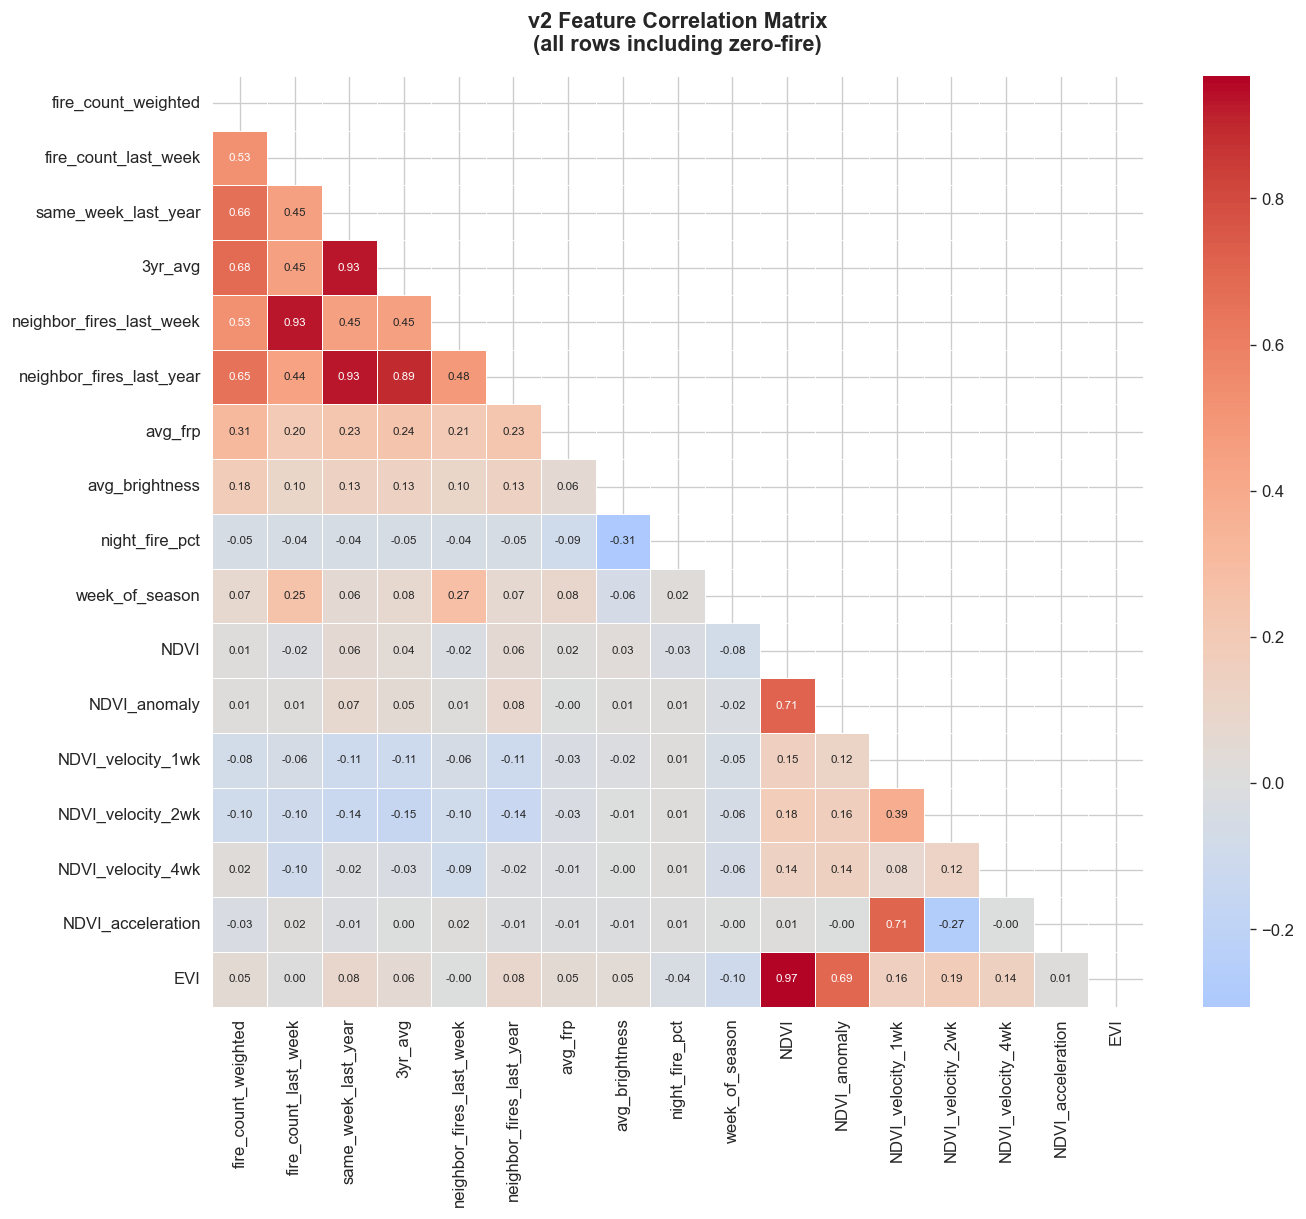

In [11]:
v2_features = [
    'fire_count_weighted',
    'fire_count_last_week', 'same_week_last_year', '3yr_avg',
    'neighbor_fires_last_week', 'neighbor_fires_last_year',
    'avg_frp', 'avg_brightness', 'night_fire_pct',
    'week_of_season',
    'NDVI', 'NDVI_anomaly',
    'NDVI_velocity_1wk', 'NDVI_velocity_2wk', 'NDVI_velocity_4wk',
    'NDVI_acceleration', 'EVI',
]

corr_all = (grid_week[v2_features].corr()['fire_count_weighted']
            .drop('fire_count_weighted'))
corr_sorted = corr_all.abs().sort_values(ascending=False)

print('Feature correlations with fire_count_weighted (ALL rows including zero-fire):')
for feat in corr_sorted.index:
    val = corr_all[feat]
    bar = '█' * int(abs(val) * 40)
    sign = '+' if val >= 0 else '−'
    print(f'  {feat:<32} {sign}{abs(val):.3f}  {bar}')

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = grid_week[v2_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax,
            square=True, linewidths=0.4, annot_kws={'size': 7})
ax.set_title('v2 Feature Correlation Matrix\n(all rows including zero-fire)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig_v2_correlation_matrix.png', bbox_inches='tight')
plt.show()

---
## 12. Export + Validation Checklist

Writing `punjab_feature_table_v2.csv`, then running all validation assertions.
The script will raise an error and print diagnostics if any check fails.


In [12]:
export_cols = [
    'grid_id', 'grid_x', 'grid_y', 'year', 'week', 'week_of_season',
    'fire_count_raw', 'fire_count_weighted', 'fire_count_filtered',
    'fire_count_last_week', 'same_week_last_year', '3yr_avg',
    'neighbor_fires_last_week', 'neighbor_fires_last_year',
    'avg_frp', 'avg_brightness', 'night_fire_pct', 'avg_confidence',
    'NDVI', 'EVI', 'NDVI_baseline', 'NDVI_anomaly',
    'NDVI_velocity_1wk', 'NDVI_velocity_2wk', 'NDVI_velocity_4wk',
    'NDVI_acceleration',
]
grid_week[export_cols].to_csv('punjab_feature_table_v2.csv', index=False)
print(f'Saved punjab_feature_table_v2.csv  ({len(grid_week):,} rows, {len(export_cols)} cols)')

# ── Validation ─────────────────────────────────────────────────
n_grids = grid_week['grid_id'].nunique()
n_years = grid_week['year'].nunique()
n_weeks = grid_week['week'].nunique()
zero_frac = (grid_week['fire_count_weighted'] == 0).mean()
r_neigh_chk = abs(grid_week[['fire_count_weighted','neighbor_fires_last_week']].corr().iloc[0,1])

ndvi_rows   = grid_week.dropna(subset=['NDVI','NDVI_anomaly'])
ndvi_vel_corr = abs(ndvi_rows[['fire_count_weighted','NDVI_velocity_2wk']].corr().iloc[0,1])
ndvi_raw_corr = abs(ndvi_rows[['fire_count_weighted','NDVI']].corr().iloc[0,1])
print(f'NDVI check (on {len(ndvi_rows):,} non-NaN rows): '
      f'velocity_2wk |corr|={ndvi_vel_corr:.4f}  raw NDVI |corr|={ndvi_raw_corr:.4f}')

checks = {
    f'Total rows == {n_grids} grids × {n_years} years × {n_weeks} weeks':
        len(grid_week) == n_grids * n_years * n_weeks,
    'Zero-fire rows present (>30%)':
        zero_frac > 0.30,
    'Zero-fire rows not majority-empty (<80%)':
        zero_frac < 0.80,
    'neighbor_fires_last_week correlation < 0.7 (leakage fixed)':
        r_neigh_chk < 0.7,
    'NDVI velocity features outperform raw NDVI':
        ndvi_vel_corr > ndvi_raw_corr,
    'No NaN in target column':
        grid_week['fire_count_weighted'].isna().sum() == 0,
    'Target is non-negative':
        (grid_week['fire_count_weighted'] >= 0).all(),
}

print()
print('=' * 60)
print(' PUNJAB STUBBLE FIRE v2 — VALIDATION CHECKLIST')
print('=' * 60)
all_passed = True
for name, passed in checks.items():
    status = '✓' if passed else '✗ FAIL'
    print(f'  {status}  {name}')
    if not passed:
        all_passed = False

assert all_passed, 'One or more validation checks failed — see above'
print()
print('All validation checks passed ✅')
print('punjab_feature_table_v2.csv is ready for modeling.')

Saved punjab_feature_table_v2.csv  (56,160 rows, 26 cols)
NDVI check (on 27,759 non-NaN rows): velocity_2wk |corr|=0.0906  raw NDVI |corr|=0.0084

 PUNJAB STUBBLE FIRE v2 — VALIDATION CHECKLIST
  ✓  Total rows == 1040 grids × 6 years × 9 weeks
  ✓  Zero-fire rows present (>30%)
  ✓  Zero-fire rows not majority-empty (<80%)
  ✓  neighbor_fires_last_week correlation < 0.7 (leakage fixed)
  ✓  NDVI velocity features outperform raw NDVI
  ✓  No NaN in target column
  ✓  Target is non-negative

All validation checks passed ✅
punjab_feature_table_v2.csv is ready for modeling.
